# 02 · Ask the frozen prior, then check the video

**Does the prior erase real motion, and can a cheap flow check already
fix it?** This notebook caches the evidence shared by all gate fits.
Prior and optical-flow weights stay frozen.

Run each notebook in a fresh kernel, in order **00 → 04**. Notebook 05 is
an external visual stress test. These are offline restoration experiments:
the model may inspect the declared complete clip. They do not claim causal
forecasting or clinical diagnosis.

**The default is real data.** Export `MP_RUN_ROOT`, the AMASS and GAVD data
paths, and the model configuration before opening Jupyter. See the
[launch guide](../../../../../slurm/motion-preservation/README.md).
For a CPU walkthrough of the mechanics, explicitly choose `MP_MODE=demo`
and a separate run directory. Demo outputs cannot establish a research result.

[Proposal](../../../../../docs/studies/motion-preservation/protocol/proposal.md)
· [Notebook guide](../../../../../notebooks/motion_preservation/README.md)

In [1]:
from pathlib import Path
import json
import os
import sys
from time import perf_counter

project_override = os.environ.get("GAVD6_ROOT")
candidates = ([Path(project_override).expanduser()] if project_override else
              [Path.cwd(), *Path.cwd().parents])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the gavd6 checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)  # Resolve manifest/config paths from the checkout in every kernel.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, Video, display
from gavd6_sjepa.research_directions.motion_preservation import workflow, plots

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
cfg = workflow.config_from_environment()
RUN_ROOT = Path(cfg.run_root)
print(f"Mode: {cfg.mode}; run directory: {RUN_ROOT}")
if cfg.mode == "demo":
    display(Markdown("**DEMO ONLY: generated fixtures and stand-in models. "
                     "These outputs are not evidence about AMASS, GAVD, or a pretrained prior.**"))

Mode: real; run directory: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/motion-preservation/pilot-01


## 1. What the prior and flow branches contribute

The motion prior proposes a repaired trajectory. Optical flow estimates
how visible image locations move between adjacent frames. For projected
path `q` and flow field `u`, the transport residual is

`r[t] = q[t+1] - q[t] - u[t](../../../../../notebooks/motion_preservation/q[t])`.

Small residual means the path agrees with nearby image movement. It does
not prove anatomical correctness. A sleeve or shoe can move differently
from a joint center. Use robust local samples, quality evidence and
occlusion flags. Pose and flow both come from the same images and are
not independent sensors.

In [2]:
# A numerical explanation of transport residuals, not an experiment result.
displacement = np.array([[4., 0.], [4., 0.]])
local_flow = np.array([[3.8, 0.2], [-1., 0.]])
residual = np.linalg.norm(displacement - local_flow, axis=-1)
display(pd.DataFrame({"candidate_dx": displacement[:, 0],
                      "nearby_flow_dx": local_flow[:, 0],
                      "transport_residual_pixels": residual},
                     index=["agreement example", "disagreement example"]))

,candidate_dx,nearby_flow_dx,transport_residual_pixels
agreement example,4.0,3.8,0.282843
disagreement example,4.0,-1.0,5.000000


## 2. Cache predictions on the declared development cases

The cache records the actual backend and reference origin. An imported
MoMask or MDM output must correspond to the same case and coordinate
convention. A demo smoother is not a released pretrained model.

The representation-only round trip is a separate baseline. If conversion
itself removes the event, that loss cannot be attributed entirely to
the pretrained prior. Keep its frame indices and report its error.

For real flow, start with a published checkpoint or a clearly labelled
alternate backend. Renderer-derived flow is an oracle diagnostic, never
an estimated-flow research result. Crop transforms apply to both flow
endpoints; camera compensation must be consistent on both trajectories.

Read reference flow error together with its coverage columns. The
conservative visibility check excludes occluded and unresolved surface
points. Foreground coverage is the fraction of visible source-body
pixels scored; all-pixel coverage uses the whole source image. A low
error on a small visible subset does not establish reliable whole-body
flow. MoMask inputs must use its trained rate of 20 frames per second.

In [3]:
started = perf_counter()
predictions = workflow.cache_predictions(cfg, roles=("train", "calibration", "development"))
print(f"Cached/loaded {len(predictions):,} rows in {perf_counter() - started:.1f} seconds.")
display(predictions.head(16))

/hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/hai/scratch/tedmui/vendor/momask-codes/common/quaternion.py:394: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:62.)
  v = torch.cross(v0, v1)


/hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/.venv/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Cached 8/176 cases with momask


Cached 16/176 cases with momask


...

Cached 160/176 cases with momask


Cached 168/176 cases with momask


Cached 176/176 cases with momask


Cached/loaded 176 rows in 226.7 seconds.


,case_id,role,person_id,identity,event_family,family,fixture,event_present,noise_present,source_dataset,...,mode,render_seconds,prior_id,prior_backend,flow_backend,cache_path,bridge_roundtrip_error_m,flow_reference_epe,flow_reference_coverage_all_pixels,flow_reference_coverage_foreground
0,train_0000_KIT__675_factorial_event0_noise0,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,False,False,KIT,...,real,49.101538,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,5.291903e-07,0.668386,0.021097,0.398427
1,train_0000_KIT__675_factorial_event0_noise1,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,False,True,KIT,...,real,49.104490,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.650773e-03,0.668386,0.021097,0.398427
2,train_0000_KIT__675_factorial_event1_noise0,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,True,False,KIT,...,real,49.107695,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,5.300617e-07,0.647037,0.020916,0.396237
3,train_0000_KIT__675_factorial_event1_noise1,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,True,True,KIT,...,real,49.111019,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.659515e-03,0.647037,0.020916,0.396237
4,train_0000_KIT__675_matched_real,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,matched,True,True,KIT,...,real,49.114161,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.659515e-03,0.647037,0.020916,0.396237
5,train_0000_KIT__675_matched_tracking_failure,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,matched,False,True,KIT,...,real,49.117284,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.659515e-03,0.668386,0.021097,0.398427
6,train_0000_KIT__675_matched_real_ambiguous,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,ambiguous,True,True,KIT,...,real,49.119949,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.659515e-03,NaN,0.000000,NaN
7,train_0000_KIT__675_matched_tracking_failure_a...,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,ambiguous,False,True,KIT,...,real,49.122971,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.659515e-03,NaN,0.000000,NaN
8,train_0001_KIT__3_factorial_event0_noise0,train,KIT::3,KIT::3,arm_leg_timing,arm_leg_timing,factorial,False,False,KIT,...,real,43.150300,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,1.579693e-07,0.474261,0.024709,0.487805
9,train_0001_KIT__3_factorial_event0_noise1,train,KIT::3,KIT::3,arm_leg_timing,arm_leg_timing,factorial,False,True,KIT,...,real,43.153321,momask,momask,sea_raft,/hai/scratch/tedmui/alexpose/experiments/sjepa...,9.650174e-04,0.474261,0.024709,0.487805


In [4]:
backend_columns = [c for c in predictions if any(word in c.lower()
                   for word in ("method", "backend", "prior", "flow", "reference", "origin"))]
if backend_columns:
    display(predictions[backend_columns].drop_duplicates().head(30))
else:
    print("Read the cached metadata and configuration to identify the executed backends.")

,prior_id,prior_backend,flow_backend,flow_reference_epe,flow_reference_coverage_all_pixels,flow_reference_coverage_foreground
0,momask,momask,sea_raft,0.668386,0.021097,0.398427
2,momask,momask,sea_raft,0.647037,0.020916,0.396237
6,momask,momask,sea_raft,NaN,0.000000,NaN
8,momask,momask,sea_raft,0.474261,0.024709,0.487805
10,momask,momask,sea_raft,0.467392,0.024972,0.492879
16,momask,momask,sea_raft,0.402063,0.034670,0.570314
18,momask,momask,sea_raft,0.404990,0.034802,0.571891
24,momask,momask,sea_raft,0.189250,0.006184,0.612818
26,momask,momask,sea_raft,0.188988,0.006210,0.612308
32,momask,momask,sea_raft,0.405447,0.019397,0.435073


## 3. Compare the inexpensive explanations first

Required first-pass comparisons are raw motion, the frozen prior,
smoothing, robust filtering, confidence gating, local flow propagation,
and a calibrated simple flow gate. The learned adapter should add value
beyond these. A reference-informed mixture is a diagnostic of what a
privileged choice can achieve. It is not a certified upper bound after
kinematic projection.

The proposal also calls for two-tracker disagreement, MFTIQ and compatible
HTD-Refine/H-MoRe/robust-prior-update comparisons. Check the implementation
ledger in the guide: unavailable external results remain missing
comparisons, not silently replaced or counted as executed baselines.

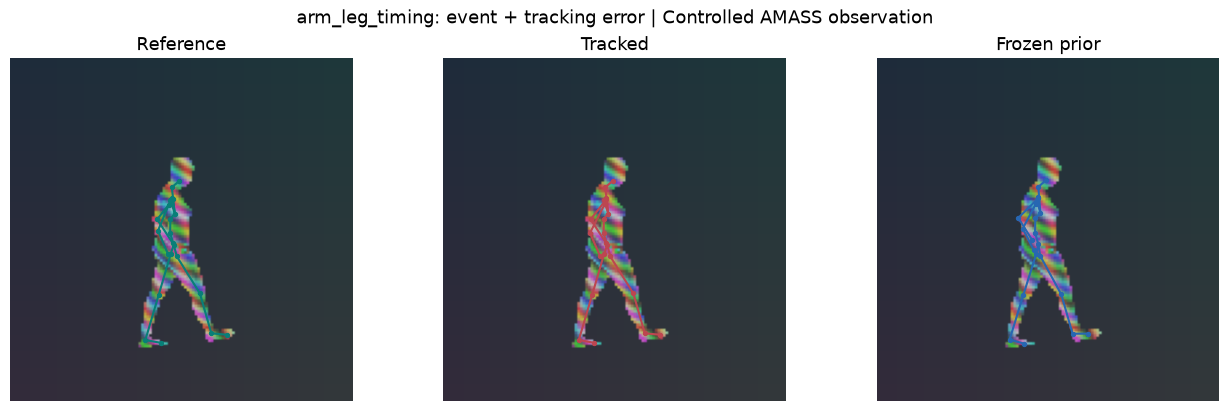

In [5]:
figure = plots.preview_pair(cfg, split="train")
display(figure)
plt.close(figure)

## 4. Measure unmodified-prior event erasure before training

Compare the raw input, representation-only round trip, unmodified prior
and inexpensive baselines on development people now. This can reveal
that conversion causes the loss, that the prior does not erase the
selected event, or that a simple rule already repairs it.

These are full-strength, unmatched operating points. The table and plot
are mechanism diagnostics, not the later calibration-locked primary
comparison. Inspect achieved noise removal as well as retention.

,method,retention,noise_removal,descriptor_abs_error,mse_m2,observed_mse_m2,completion_mse_m2,missing_fraction,n_people,event_and_noise_removal,unedited_motion_descriptor_error,coverage,brier,selective_accuracy,ambiguous_brier,ambiguous_coverage
0,raw,0.855359,0.000000,0.011682,0.000027,0.000027,0.000159,0.000541,8,0.000000,0.005267,NaN,NaN,NaN,NaN,NaN
1,projected_raw,0.786111,-0.546982,0.019597,0.000040,0.000040,0.000174,0.000541,8,-0.538877,0.012269,NaN,NaN,NaN,NaN,NaN
2,prior,0.320104,-86.811653,0.043422,0.002447,0.002444,0.006331,0.000541,8,-87.969064,0.012509,NaN,NaN,NaN,NaN,NaN
3,conversion_only,0.786111,-0.546983,0.019597,0.000040,0.000040,0.000174,0.000541,8,-0.538878,0.012269,NaN,NaN,NaN,NaN,NaN
4,prior_unprojected,0.332565,-86.365216,0.041677,0.002423,0.002420,0.006055,0.000541,8,-87.472473,0.011953,NaN,NaN,NaN,NaN,NaN
5,conversion_only_unprojected,0.768113,-1.056627,0.022345,0.000055,0.000055,0.000280,0.000541,8,-1.055767,0.013827,NaN,NaN,NaN,NaN,NaN
6,gaussian,0.857881,-2.938857,0.012913,0.000122,0.000122,0.000111,0.000541,8,-2.937232,0.009591,NaN,NaN,NaN,NaN,NaN
7,median,0.871356,-3.546826,0.012184,0.000146,0.000146,0.000121,0.000541,8,-3.557863,0.009467,NaN,NaN,NaN,NaN,NaN
8,kalman,0.740801,-5.334908,0.023015,0.000199,0.000199,0.000184,0.000541,8,-4.998046,0.014148,NaN,NaN,NaN,NaN,NaN
9,confidence_gate,0.880105,-3.683168,0.014069,0.000129,0.000127,0.002756,0.000541,8,-3.684733,0.010286,NaN,NaN,NaN,NaN,NaN


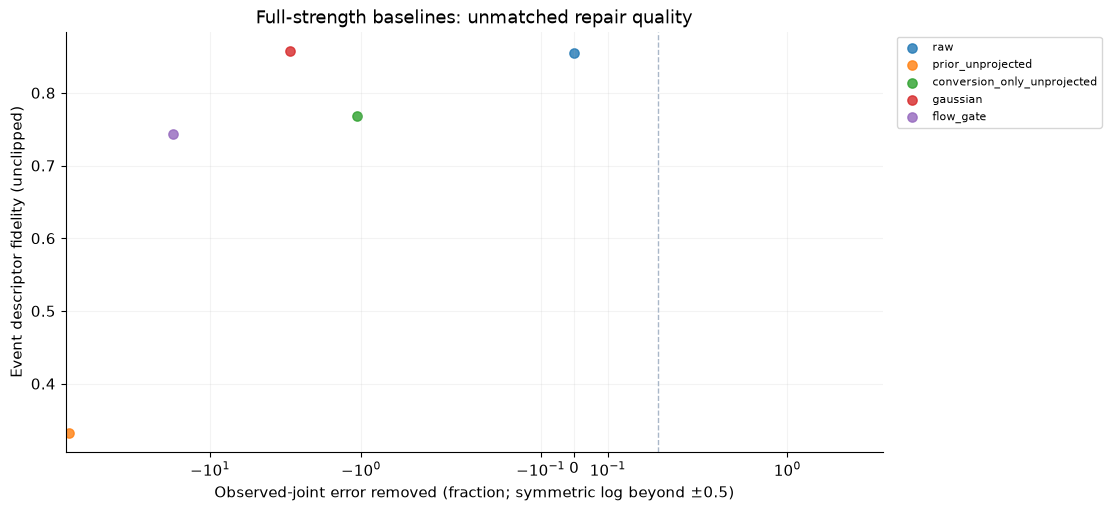

In [6]:
baseline_report = workflow.baseline_report(cfg, split="development")
display(baseline_report["summary"])
figure = plots.plot_tradeoff(baseline_report)
figure.axes[0].set_title("Full-strength baselines: unmatched repair quality")
display(figure)
plt.close(figure)

## 5. Does the proposed gate have room to help?

A mixture can retain some of the raw-minus-prior residual, but it cannot
invent a correct movement absent from both candidates. The
reference-informed mixture diagnostic uses known truth to choose each
weight before projection. Its post-projection score is not a mathematical
ceiling. Poor performance is a reason to inspect whether this gate design
has enough expressive power. If a simple flow rule succeeds equally well,
the full learned model needs a stronger reason to exist.

This is the 24-hour mechanism check. Do not tune using the final event
family. A held-person development result comes after calibration in
notebooks 03 and 04.

Next: [03 · Train and calibrate](03_train_and_calibrate.ipynb).